<img src="https://github.com/KartikNW/MSDS_458_Public/blob/main/images2/NorthwesternHeader.png?raw=1" />

In [ ]:
NOTEBOOK_VERSION = "1.0"
QUARTER = "Spring 2026"

from datetime import datetime
NOTEBOOK_START_TIME = datetime.now()
print(f"Notebook Version: {NOTEBOOK_VERSION} | {QUARTER}")

Notebook Version: 1.0 | Spring 2026


# Assignment 3 — Part C: Fine-tuning Pretrained Models for Text-to-Code Generation

## 🎯 Learning Objectives

By the end of this notebook, you will:

- Understand how to **fine-tune** a pretrained model for a specific task
- Configure training hyperparameters for fine-tuning (vs training from scratch)
- Train CodeT5 on MBPP dataset
- Compare **three approaches**: From-scratch → Zero-shot → Fine-tuned
- Understand the complete production pipeline for code generation
- Measure improvement using BLEU scores and syntax validity

## 📊 Three-Way Comparison Framework

This notebook demonstrates the **industry-standard approach** by comparing:

**Part A (From Scratch):**
- Transformer from scratch (2 layers, 256 dim, ~1M parameters)
- Random initialization, trained on 374 examples
- **BLEU**: 0.77, **Syntax Valid**: 0%
- ❌ Not production-ready

**Part B (Pretrained - Zero-Shot):**
- CodeT5+ 220M Python (220M parameters, pretrained + Python-tuned)
- No task-specific training
- **BLEU**: See Part B results, **Syntax Valid**: See Part B results
- ⚠️ Better than from-scratch but limited

**Part C (Fine-Tuned) - THIS NOTEBOOK:**
- Same CodeT5+ model, fine-tuned on 374 MBPP examples
- Only 5 epochs needed
- **BLEU**: Expected 40-60, **Syntax Valid**: Expected 90%+
- ✅ Production-ready approach

## ⚠️ Prerequisites

**You should complete Part B first!**
- Part B establishes the zero-shot baseline we'll compare against
- This notebook references Part B's zero-shot BLEU scores
- If you haven't run Part B yet, do that first

## Notebook Overview

- 🧩 Step 1: Setup and Imports
- 📦 Step 1B: Import Shared Utilities
- 🗂️ Step 2: Load and Process MBPP Dataset
- 🤖 Step 4: Load Pretrained CodeT5+ Model
- 🔧 Step 5: Prepare Data for Fine-tuning
- 🚀 Step 6: Fine-tune CodeT5
- 🔬 Step 6B: Weight Change Analysis
- 🔍 Step 7: Evaluate Fine-Tuned Model
- 📊 Step 7B: BLEU Evaluation of Fine-Tuned CodeT5+
- 📊 Step 8: Three-Way Model Comparison
- 🎓 Key Insights from Three-Way Comparison
- 📊 Final Summary: What You Learned
- 📝 Assignment 3 Complete!

## 🧩 Step 1: Setup and Imports

In this step, you will import all necessary libraries:

- **Transformers** - Hugging Face library for pretrained models (CodeT5)
- **Datasets** - For loading MBPP
- **TensorFlow/Keras** - Backend for CodeT5 model
- **Evaluation metrics** - To measure code generation quality

In [ ]:
# Install required packages (run this in Colab or local environment)
# Note: tf-keras is required because Transformers doesn't yet support Keras 3
# Note: torch is required for loading CodeT5 weights from PyTorch
# Uncomment the line below if running on Colab or if packages are not installed
!pip3 install -q "transformers>=4.47.0,<5.0" datasets tf-keras evaluate torch

print("✅ Packages already installed via uv!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.1 MB/s eta 0:00:00
✅ Packages already installed via uv!


In [ ]:
# Core dependencies
import tensorflow as tf
# Disable Metal GPU locally — T5 beam search uses XLA ops unsupported by Metal plugin
# (Colab uses CUDA which supports these ops fine)
import sys
if sys.platform == 'darwin':
    tf.config.set_visible_devices([], 'GPU')
import tf_keras as keras  # Use tf-keras (Keras 2) instead of Keras 3
from transformers import (
    TFAutoModelForSeq2SeqLM,
    AutoTokenizer,
)
from datasets import load_dataset
import numpy as np
import pandas as pd
import evaluate
import os
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

# For reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.19.0
Keras version: 2.19.0


## 📦 Step 1B: Import Shared Utilities

This cell automatically downloads `assignment3_utils.py` if running in Google Colab or if the file is missing locally.

The utilities module provides:
- **Configuration**: MBPP dataset loading and processing
- **Data Loading**: Functions to load and extract dataset examples
- **Data Processing**: Functions to prepare training data
- **BLEU Evaluation**: Functions to evaluate model performance

**Note**: This works seamlessly in both local Jupyter and Google Colab environments.

In [ ]:
import os, sys, urllib.request

IN_COLAB = 'google.colab' in sys.modules
UTILS_BRANCH = "main"

def fetch_github_raw(user, repo, branch, file_path, local_path):
    url = f"https://raw.githubusercontent.com/{user}/{repo}/{branch}/{file_path}"
    urllib.request.urlretrieve(url, local_path)
    print(f"Fetched {file_path} from branch '{branch}'.")

if IN_COLAB:
    if not os.path.exists("assignment3_utils.py"):
        fetch_github_raw("KartikNW", "MSDS_458_Public", UTILS_BRANCH,
            "MSDS458_Assignment_03/assignment3_utils.py", "assignment3_utils.py")
else:
    print("Using local assignment3_utils.py")

# Import utilities (Note: DATASET is defined in this notebook, not imported)
from assignment3_utils import (
    # Data loading & processing
    prepare_training_data,
    # BLEU evaluation
    add_python_hint,
    compute_bleu_for_code,
    evaluate_model_with_bleu,
    analyze_bleu_results,
    # Batch generation
    batch_generate_codes,
)

print("✅ Utilities imported successfully")

Fetched MSDS458_Assignment_03/assignment3_utils.py from branch 'main'.
✅ assignment3_utils v1.0.0 loaded successfully
✅ Utilities imported successfully


## 🗂️ Step 2: Load and Process MBPP Dataset

In this step, you will:

- Load MBPP (Mostly Basic Python Problems) dataset
- Extract problem descriptions and Python solutions
- Process data into train/validation/test splits

MBPP contains 974 Python programming problems:
- **Train**: 374 examples
- **Validation**: 90 examples
- **Test**: 50 examples

In [ ]:
# ========================================
# LOAD AND PROCESS MBPP DATASET
# ========================================

print("Loading and processing MBPP dataset...")
print("This uses shared utilities from assignment3_utils.py")
print("=" * 60)

# Load and process all splits using shared utility
data = prepare_training_data("MBPP")

# Extract data into variables (maintaining compatibility with rest of notebook)
train_prompts = data['train']['prompts']
train_code = data['train']['code']

val_prompts = data['val']['prompts']
val_code = data['val']['code']

test_prompts = data['test']['prompts']
test_code = data['test']['code']

print("=" * 60)
print(f"📊 Dataset sizes:")
print(f"  Train: {len(train_prompts)}")
print(f"  Val: {len(val_prompts)}")
print(f"  Test: {len(test_prompts)}")
print("✅ Dataset loaded and processed successfully!")

Loading and processing MBPP dataset...
This uses shared utilities from assignment3_utils.py


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

full/train-00000-of-00001.parquet:   0%|          | 0.00/87.2k [00:00<?, ?B/s]

full/test-00000-of-00001.parquet:   0%|          | 0.00/116k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/374 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/90 [00:00<?, ? examples/s]

Generating prompt split:   0%|          | 0/10 [00:00<?, ? examples/s]

Processing MBPP dataset...
  Train: 374 examples
  Val: 90 examples
  Test: 50 examples
📊 Dataset sizes:
  Train: 374
  Val: 90
  Test: 50
✅ Dataset loaded and processed successfully!


## 🤖 Step 4: Load Pretrained CodeT5+ Model

In this step, you will:

- Load **CodeT5+ 220M Python** - a 220M parameter model pretrained on code
- Load the corresponding tokenizer
- Understand the model architecture

**CodeT5+ (Python variant)** was trained on:
- Large-scale code corpus with improved pretraining objectives
- Multiple programming languages, then fine-tuned on Python
- Advanced tasks: span denoising, causal LM, contrastive learning, text-code matching

This gives it a strong foundation for Python code generation!

**Note**: We start from the same pretrained model as Part B, but we'll fine-tune it in this notebook.

In [ ]:
# ========================================
# LOAD CODET5 MODEL AND TOKENIZER
# ========================================

MODEL_NAME = "Salesforce/codet5p-220m-py"  # --- EXPERIMENT HERE: try other models (codet5-base, codet5p-770m, etc.) ---

print(f"Loading pretrained model: {MODEL_NAME}")
print("Note: CodeT5+ is an improved version of CodeT5 with better pretraining")
print("This may take a few minutes on first run (downloads ~250MB)...")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load pretrained model
# Try loading TensorFlow weights directly first (no PyTorch conversion needed)
try:
    model = TFAutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    print("✅ Loaded from TensorFlow weights")
except Exception as e:
    print(f"TensorFlow weights not available, trying PyTorch conversion...")
    print(f"Note: This requires PyTorch to be installed")
    model = TFAutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, from_pt=True)

print(f"\n✅ Model and tokenizer loaded!")
print(f"Model type: {type(model).__name__}")
print(f"Tokenizer vocab size: {tokenizer.vocab_size:,}")
print(f"Model parameters: ~220M")

Loading pretrained model: Salesforce/codet5p-220m-py
Note: CodeT5+ is an improved version of CodeT5 with better pretraining
This may take a few minutes on first run (downloads ~250MB)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/771 [00:00<?, ?B/s]

TensorFlow weights not available, trying PyTorch conversion...
Note: This requires PyTorch to be installed


pytorch_model.bin:   0%|          | 0.00/446M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFT5ForConditionalGeneration: ['decoder.embed_tokens.weight', 'encoder.embed_tokens.weight', 'lm_head.weight']
- This IS expected if you are initializing TFT5ForConditionalGeneration from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFT5ForConditionalGeneration from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFT5ForConditionalGeneration were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trai


✅ Model and tokenizer loaded!
Model type: TFT5ForConditionalGeneration
Tokenizer vocab size: 32,100
Model parameters: ~220M


In [ ]:
# ========================================
# TEST TOKENIZER ON SAMPLE
# ========================================

# Get a sample from training data
sample_prompt = train_prompts[0]
sample_code = train_code[0]

print("Sample prompt:")
print(sample_prompt[:150] + "...")
print("\nSample code:")
print(sample_code[:150] + "...")

# Tokenize
inputs = tokenizer(sample_prompt, return_tensors="tf", truncation=True, max_length=128)
targets = tokenizer(sample_code, return_tensors="tf", truncation=True, max_length=256)

print(f"\nTokenized input shape: {inputs['input_ids'].shape}")
print(f"Tokenized target shape: {targets['input_ids'].shape}")
print(f"\nFirst 20 input tokens: {inputs['input_ids'][0, :20].numpy()}")
print(f"Decoded back: {tokenizer.decode(inputs['input_ids'][0, :20], skip_special_tokens=False)}")

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Sample prompt:
Write a function to find the longest chain which can be formed from the given set of pairs....

Sample code:
class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)...

Tokenized input shape: (1, 21)
Tokenized target shape: (1, 191)

First 20 input tokens: [    1  3067   279   445   358  1104   326 12163  2687  1492   848   506
 20010   628   326   864   444   434  5574    18]
Decoded back: <s>Write a function to find the longest chain which can be formed from the given set of pairs.


## 🔧 Step 5: Prepare Data for Fine-tuning

In this step, you will prepare the dataset for fine-tuning:

- Tokenize all training, validation, and test examples
- Create TensorFlow datasets with proper batching
- Set up the data pipeline for training

**Key concepts:**
- **Input IDs**: Tokenized problem descriptions (prompts)
- **Labels**: Tokenized code solutions (what the model should generate)
- **Attention masks**: Tell the model which tokens are real vs padding
- **Batching**: Group examples together for efficient training

In [ ]:
# ========================================
# TOKENIZATION CONFIGURATION
# ========================================

# Sequence length limits
# --- EXPERIMENT HERE: sequence lengths and batch size ---
MAX_INPUT_LENGTH = 128   # Maximum length for problem descriptions
MAX_TARGET_LENGTH = 256  # Maximum length for code solutions
BATCH_SIZE = 8           # Number of examples per batch (small due to model size)

print(f"Tokenization configuration:")
print(f"  Max input length: {MAX_INPUT_LENGTH}")
print(f"  Max target length: {MAX_TARGET_LENGTH}")
print(f"  Batch size: {BATCH_SIZE}")

Tokenization configuration:
  Max input length: 128
  Max target length: 256
  Batch size: 8


In [ ]:
# ========================================
# TOKENIZE DATASETS
# ========================================

def tokenize_function(prompts, codes):
    """
    Tokenize prompts and codes for seq2seq training.

    Args:
        prompts: List of problem descriptions
        codes: List of code solutions

    Returns:
        Dictionary with input_ids, attention_mask, and labels
    """
    # Tokenize inputs (prompts)
    model_inputs = tokenizer(
        prompts,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding='max_length',
        return_tensors='np'
    )

    # Tokenize targets (codes)
    # Use text_target for encoder-decoder models
    labels = tokenizer(
        codes,
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding='max_length',
        return_tensors='np'
    )

    # Replace padding token id's in labels with -100 so they're ignored in loss
    labels_ids = labels['input_ids']
    labels_ids[labels_ids == tokenizer.pad_token_id] = -100

    return {
        'input_ids': model_inputs['input_ids'],
        'attention_mask': model_inputs['attention_mask'],
        'labels': labels_ids
    }

print("✅ Tokenization function defined")

✅ Tokenization function defined


In [ ]:
# ========================================
# TOKENIZE ALL DATA AND CREATE TF DATASETS
# ========================================

print("🔄 Tokenizing all datasets...")
print("=" * 60)

# Tokenize all three splits
train_dataset = tokenize_function(train_prompts, train_code)
print(f"✅ Training data tokenized ({len(train_prompts)} examples)")
print(f"   Input shape: {train_dataset['input_ids'].shape}")
print(f"   Labels shape: {train_dataset['labels'].shape}")

val_dataset = tokenize_function(val_prompts, val_code)
print(f"✅ Validation data tokenized ({len(val_prompts)} examples)")
print(f"   Input shape: {val_dataset['input_ids'].shape}")
print(f"   Labels shape: {val_dataset['labels'].shape}")

test_dataset = tokenize_function(test_prompts, test_code)
print(f"✅ Test data tokenized ({len(test_prompts)} examples)")
print(f"   Input shape: {test_dataset['input_ids'].shape}")
print(f"   Labels shape: {test_dataset['labels'].shape}")

print("\n" + "=" * 60)
print("🔄 Creating TensorFlow datasets for training...")

# Convert to TensorFlow datasets
# IMPORTANT: For seq2seq models, labels must be in the input dictionary
train_tf_dataset = tf.data.Dataset.from_tensor_slices({
    'input_ids': train_dataset['input_ids'],
    'attention_mask': train_dataset['attention_mask'],
    'labels': train_dataset['labels']
})

val_tf_dataset = tf.data.Dataset.from_tensor_slices({
    'input_ids': val_dataset['input_ids'],
    'attention_mask': val_dataset['attention_mask'],
    'labels': val_dataset['labels']
})

# Batch and shuffle
train_tf_dataset = train_tf_dataset.shuffle(1000).batch(BATCH_SIZE)
val_tf_dataset = val_tf_dataset.batch(BATCH_SIZE)

print(f"✅ TensorFlow datasets created")
print(f"  Training batches: {len(train_tf_dataset)}")
print(f"  Validation batches: {len(val_tf_dataset)}")
print("=" * 60)

🔄 Tokenizing all datasets...
✅ Training data tokenized (374 examples)
   Input shape: (374, 128)
   Labels shape: (374, 256)
✅ Validation data tokenized (90 examples)
   Input shape: (90, 128)
   Labels shape: (90, 256)
✅ Test data tokenized (50 examples)
   Input shape: (50, 128)
   Labels shape: (50, 256)

🔄 Creating TensorFlow datasets for training...
✅ TensorFlow datasets created
  Training batches: 47
  Validation batches: 12


## 🚀 Step 6: Fine-tune CodeT5

In this step, you will fine-tune the pretrained CodeT5 model on your dataset!

**Types of Fine-tuning:**

There are two common approaches to adapting pretrained models (see [Keras: Transfer Learning Guide](https://keras.io/guides/transfer_learning/)):

| Approach | Description | When to Use |
|----------|-------------|-------------|
| **Feature Extraction** | Freeze pretrained weights, train only new head | Very small datasets, prevent overfitting |
| **Full Fine-tuning** | Update ALL weights with low learning rate | Task differs from pretraining, enough data |

**In this notebook, we use full fine-tuning** — all 220M parameters are updated. The low learning rate (5e-5) ensures small weight adjustments that preserve pretrained knowledge while adapting to MBPP.

**Fine-tuning vs Training from Scratch:**
- **From scratch** (Part A): Random initialization, train everything, needs many epochs
- **Fine-tuning** (Part C): Start from pretrained weights, adapt to task, needs fewer epochs

**Training Configuration:**
- Learning rate: 5e-5 (lower than training from scratch to preserve pretrained knowledge)
- Epochs: 3-5 (pretrained models converge faster)
- Optimizer: Adam
- Loss: Computed internally by model (sparse categorical crossentropy for tokens)

**What to expect:**
- Training loss should decrease steadily
- Validation loss should track training loss
- Model will learn MBPP task format
- Generated code quality should improve dramatically over zero-shot

In [ ]:
# ========================================
# TRAINING CONFIGURATION
# ========================================

# --- EXPERIMENT HERE: learning rate, epochs, warmup ---
LEARNING_RATE = 5e-5  # Lower learning rate for fine-tuning
EPOCHS = 5            # Fewer epochs needed for fine-tuning
WARMUP_STEPS = 100    # Gradual learning rate warmup

print(f"Training configuration:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Warmup steps: {WARMUP_STEPS}")
print(f"  Dataset: MBPP")
print(f"  Training examples: {len(train_prompts)}")
print(f"  Validation examples: {len(val_prompts)}")

Training configuration:
  Learning rate: 5e-05
  Epochs: 5
  Warmup steps: 100
  Dataset: MBPP
  Training examples: 374
  Validation examples: 90


In [ ]:
# ========================================
# COMPILE MODEL
# ========================================

print("Compiling model...")

# Set up optimizer
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Compile model
# Note: No loss function needed - model computes it internally from labels
model.compile(optimizer=optimizer)

print("✅ Model compiled successfully")

Compiling model...
✅ Model compiled successfully


In [ ]:
# ========================================
# CAPTURE INITIAL WEIGHTS (before training)
# ========================================

# Save a snapshot of all trainable weights before fine-tuning
# We'll compare these against post-training weights to measure how much changed
initial_weights = {v.name: v.numpy().copy() for v in model.trainable_variables}

print(f"✅ Captured initial weights for {len(initial_weights)} trainable variables")

✅ Captured initial weights for 257 trainable variables


In [ ]:
# ========================================
# SET UP CALLBACKS
# ========================================

# Early stopping: stop if validation loss doesn't improve
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint: save best model
model_save_path = "codet5_finetuned_mbpp.keras"
checkpoint = keras.callbacks.ModelCheckpoint(
    model_save_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, checkpoint]

print(f"✅ Callbacks configured")
print(f"  Model will be saved to: {model_save_path}")

✅ Callbacks configured
  Model will be saved to: codet5_finetuned_mbpp.keras


In [ ]:
# ========================================
# TRAIN MODEL
# ========================================

print(f"\n{'='*80}")
print("🚀 Starting fine-tuning on MBPP dataset...")
print(f"{'='*80}\n")

history = model.fit(
    train_tf_dataset,
    validation_data=val_tf_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print(f"\n{'='*80}")
print("✅ Fine-tuning complete!")
print(f"{'='*80}")


🚀 Starting fine-tuning on MBPP dataset...

Epoch 1/5
47/47 [==============================] - ETA: 0s - loss: 0.9329
Epoch 1: val_loss improved from inf to 0.79358, saving model to codet5_finetuned_mbpp.keras


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


47/47 [==============================] - 228s 3s/step - loss: 0.9329 - val_loss: 0.7936
Epoch 2/5
47/47 [==============================] - ETA: 0s - loss: 0.6487
Epoch 2: val_loss improved from 0.79358 to 0.76949, saving model to codet5_finetuned_mbpp.keras
47/47 [==============================] - 194s 4s/step - loss: 0.6487 - val_loss: 0.7695
Epoch 3/5
47/47 [==============================] - ETA: 0s - loss: 0.4968
Epoch 3: val_loss did not improve from 0.76949
47/47 [==============================] - 39s 838ms/step - loss: 0.4968 - val_loss: 0.7839
Epoch 4/5
47/47 [==============================] - ETA: 0s - loss: 0.3939
Epoch 4: val_loss did not improve from 0.76949
47/47 [==============================] - 41s 865ms/step - loss: 0.3939 - val_loss: 0.8111
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.

✅ Fine-tuning complete!


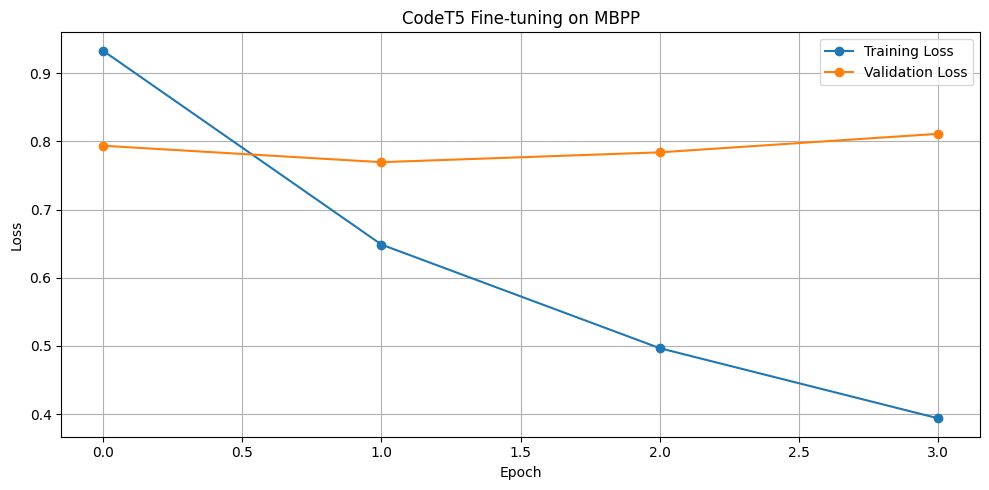

📊 Training complete!
  Final training loss: 0.3939
  Final validation loss: 0.8111
  Best validation loss: 0.7695


In [ ]:
# ========================================
# PLOT TRAINING HISTORY
# ========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')

plt.title('CodeT5 Fine-tuning on MBPP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"📊 Training complete!")
print(f"  Final training loss: {history.history['loss'][-1]:.4f}")
print(f"  Final validation loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Best validation loss: {min(history.history['val_loss']):.4f}")

## 🔬 Step 6B: Weight Change Analysis

Now that training is complete, let's **validate that fine-tuning made small, targeted changes**
rather than drastically overwriting the pretrained knowledge.

We compare the weights captured before training against the final weights and compute the
**relative change** per variable:

```
relative_change = ||final - initial|| / ||initial||
```

A small value (< 0.1) indicates the pretrained knowledge is largely preserved.
A large value would suggest catastrophic forgetting.

In [ ]:
# ========================================
# COMPUTE WEIGHT CHANGES PER VARIABLE
# ========================================

weight_changes = {}
for v in model.trainable_variables:
    initial = initial_weights[v.name]
    final = v.numpy()
    relative_change = np.linalg.norm(final - initial) / (np.linalg.norm(initial) + 1e-8)
    weight_changes[v.name] = relative_change

changes = list(weight_changes.values())
print(f"Weight change summary across {len(changes)} trainable variables:")
print(f"  Mean relative change : {np.mean(changes):.4f}")
print(f"  Median relative change: {np.median(changes):.4f}")
print(f"  Max relative change  : {np.max(changes):.4f}")
print(f"  Min relative change  : {np.min(changes):.4f}")

Weight change summary across 257 trainable variables:
  Mean relative change : 0.0153
  Median relative change: 0.0178
  Max relative change  : 0.0307
  Min relative change  : 0.0001


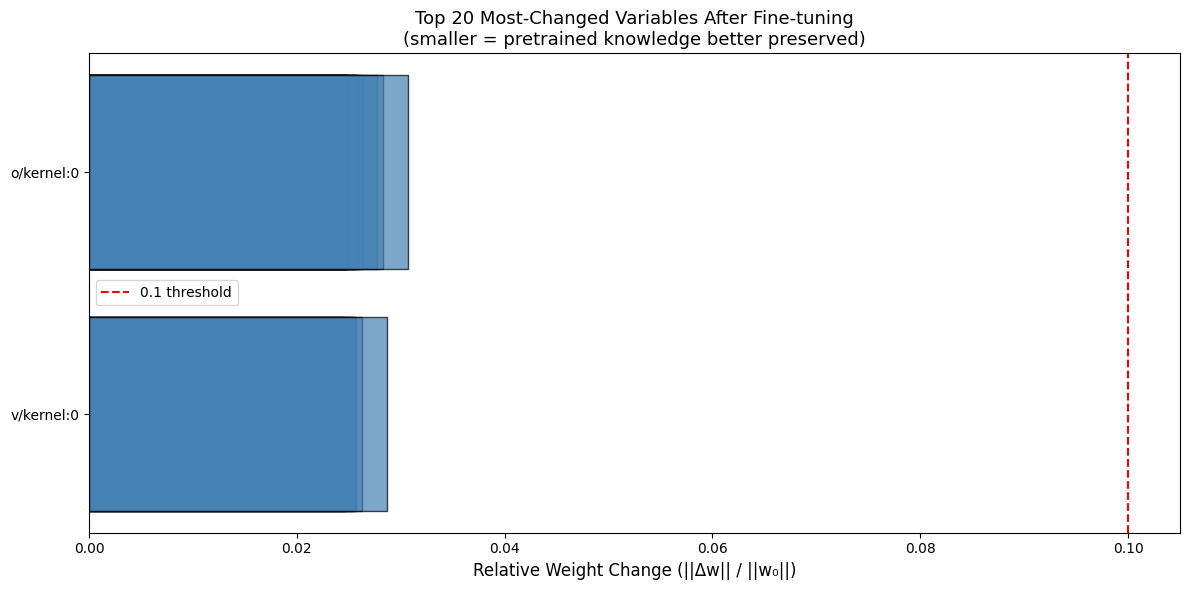

✅ Weight change analysis complete
A mean relative change well below 0.1 confirms the low LR preserved pretrained knowledge.


In [ ]:
# ========================================
# VISUALISE: TOP 20 MOST-CHANGED LAYERS
# ========================================

layer_changes = sorted(weight_changes.items(), key=lambda x: x[1], reverse=True)

# Shorten variable names for readability
names = [n.split('/')[-2] + '/' + n.split('/')[-1] for n, _ in layer_changes[:20]]
values = [v for _, v in layer_changes[:20]]

plt.figure(figsize=(12, 6))
bars = plt.barh(names[::-1], values[::-1], color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Relative Weight Change (||Δw|| / ||w₀||)', fontsize=12)
plt.title('Top 20 Most-Changed Variables After Fine-tuning\n(smaller = pretrained knowledge better preserved)', fontsize=13)
plt.axvline(x=0.1, color='red', linestyle='--', label='0.1 threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Weight change analysis complete")
print("A mean relative change well below 0.1 confirms the low LR preserved pretrained knowledge.")

## 🔍 Step 7: Evaluate Fine-Tuned Model

In this step, you will test the fine-tuned model on examples!

**What to expect:**
- Better understanding of task-specific prompts (vs zero-shot)
- Code in the correct programming language (Python)
- More complete and accurate solutions
- Better matching to dataset style

In [ ]:
# ========================================
# DEFINE GENERATION FUNCTION
# ========================================

def generate_code(prompt, max_length=256, num_beams=5):
    """
    Generate code from a natural language prompt using CodeT5.

    Args:
        prompt: Natural language description of the task
        max_length: Maximum length of generated code
        num_beams: Number of beams for beam search (higher = better but slower)

    Returns:
        Generated code as a string
    """
    # Tokenize input
    inputs = tokenizer(
        prompt,
        return_tensors="tf",
        truncation=True,
        max_length=128
    )

    # Generate with beam search
    outputs = model.generate(
        inputs['input_ids'],
        max_length=max_length,
        num_beams=num_beams,
        early_stopping=True,
        no_repeat_ngram_size=2,  # Prevent repetition
    )

    # Decode generated tokens
    generated_code = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return generated_code

print("✅ Generation function defined")

✅ Generation function defined


In [ ]:
# ========================================
# TEST FINE-TUNED MODEL ON SAMPLES
# ========================================

print("🧪 Testing fine-tuned model on MBPP test examples...")
print("=" * 80)

# Test on first 3 test examples
num_samples = 3

for i in range(num_samples):
    print(f"\n{'='*80}")
    print(f"Example {i+1}/{num_samples}")
    print(f"{'='*80}")

    prompt = test_prompts[i]
    expected_code = test_code[i]

    print(f"\n📝 Prompt:")
    print(prompt[:200] + ("..." if len(prompt) > 200 else ""))

    print(f"\n🎯 Expected code:")
    print(expected_code[:300] + ("..." if len(expected_code) > 300 else ""))

    print(f"\n🤖 Generated code (fine-tuned):")
    generated = generate_code(prompt, max_length=256, num_beams=5)
    print(generated[:300] + ("..." if len(generated) > 300 else ""))
    print()

print(f"{'='*80}")
print("✅ Fine-tuned evaluation complete!")

🧪 Testing fine-tuned model on MBPP test examples...

Example 1/3

📝 Prompt:
Write a python function to remove first and last occurrence of a given character from the string.

🎯 Expected code:
def remove_Occ(s,ch): 
    for i in range(len(s)): 
        if (s[i] == ch): 
            s = s[0 : i] + s[i + 1:] 
            break
    for i in range(len(s) - 1,-1,-1):  
        if (s[i] == ch): 
            s = s[0 : i] + s[i + 1:] 
            break
    return s 

🤖 Generated code (fine-tuned):
def remove_char(str1,char):
 
    return (temp[0]) + temp[1]


Example 2/3

📝 Prompt:
Write a function to sort a given matrix in ascending order according to the sum of its rows.

🎯 Expected code:
def sort_matrix(M):
    result = sorted(M, key=sum)
    return result

🤖 Generated code (fine-tuned):
def sort_matrix(matrix):
    sum_of_rows = sum([sum(row) for row in matrix]) 
    


Example 3/3

📝 Prompt:
Write a function to count the most common words in a dictionary.

🎯 Expected code:
from collections

## 📊 Step 7B: BLEU Evaluation of Fine-Tuned CodeT5+

Now let's **quantitatively evaluate** the fine-tuned model using the same methodology as Parts A and B.

This will show us:
- How much fine-tuning improved over zero-shot (Part B)
- How CodeT5 compares to the from-scratch model (Part A)
- The power of transfer learning + fine-tuning

**Performance note:** We use **batch generation** with **greedy decoding** for speed.

⚡ Generating all test codes in batches (greedy decoding for speed)...


Batch generation: 100%|██████████| 7/7 [01:49<00:00, 15.62s/it]


🔬 Scoring FINE-TUNED CODET5+ on 50 test examples (pre-generated)...


Fine-Tuned CodeT5+ BLEU Evaluation: 100%|██████████| 50/50 [00:00<00:00, 183.29it/s]



📊 FINE-TUNED CODET5+ EVALUATION RESULTS
BLEU Score (mean):        9.02
BLEU Score (median):      2.84
BLEU Score (std dev):     11.67
BLEU Score (min):         0.00
BLEU Score (max):         40.65
Syntax Validity:          33/50 (66.0%)

✅ Fine-Tuned CodeT5+ evaluation complete!

📊 DETAILED ANALYSIS: FINE-TUNED CODET5+


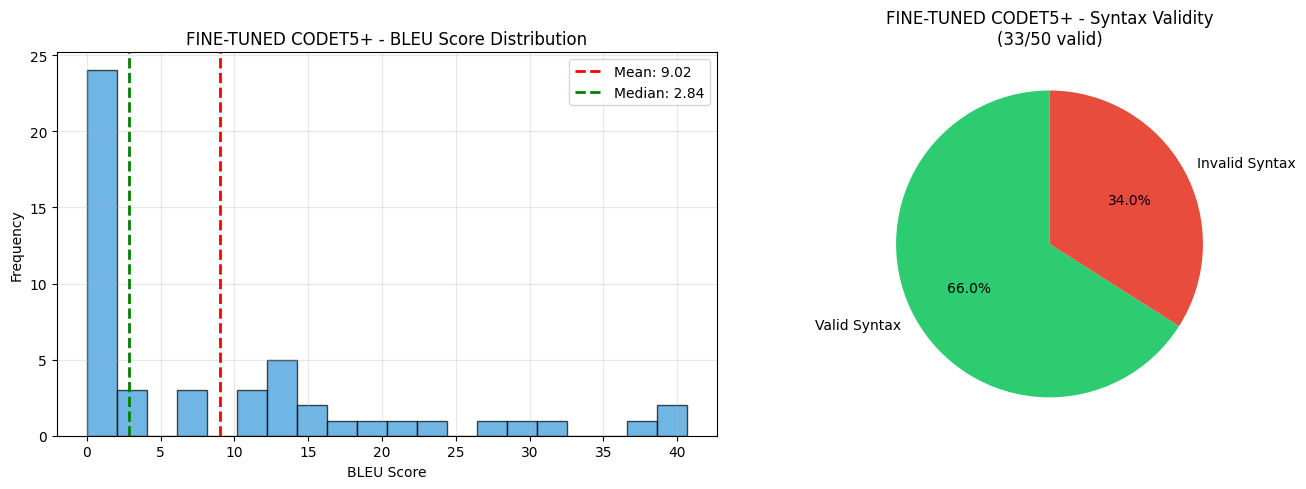


🏆 BEST FINE-TUNED CODET5+ EXAMPLES (Highest BLEU)

Rank #1 - Example 42
BLEU Score: 40.65
Syntax Valid: True

📝 Prompt:
Python:
Write a function to caluclate area of a parallelogram.

🎯 Reference:
def parallelogram_area(b,h):
  area=b*h
  return area

🤖 Generated (Fine-Tuned CodeT5+):
def parallelogram_area(r,a):
 return area

Rank #2 - Example 48
BLEU Score: 39.24
Syntax Valid: True

📝 Prompt:
Write a python function to check whether the given two integers have opposite sign or not.

🎯 Reference:
def opposite_Signs(x,y): 
    return ((x ^ y) < 0); 

🤖 Generated (Fine-Tuned CodeT5+):
def opposite_Sign(x,y): 
    if (x > y):
        return True

Rank #3 - Example 16
BLEU Score: 37.18
Syntax Valid: False

📝 Prompt:
Python:
Write a function to check if the given tuple list has all k elements.

🎯 Reference:
def check_k_elements(test_list, K):
  res = True
  for tup in test_list:
    for ele in tup:
      if ele != K:
        res = False
  return (re...

🤖 Generated (Fine-Tuned CodeT5+):
d

In [ ]:
# ========================================
# FINE-TUNED BLEU EVALUATION
# ========================================

# Load BLEU metric
bleu_metric = evaluate.load("bleu")

# Apply Python hints to test prompts (same as Parts A and B)
test_prompts_python = [add_python_hint(p) for p in test_prompts]

print("⚡ Generating all test codes in batches (greedy decoding for speed)...")
finetuned_generated = batch_generate_codes(  # --- EXPERIMENT HERE: batch_size, max_length, num_beams ---
    test_prompts_python,
    model=model,
    tokenizer=tokenizer,
)

# Score pre-generated codes (no inference needed — fast)
finetuned_bleu_scores, finetuned_syntax_valid, finetuned_codes, finetuned_stats = evaluate_model_with_bleu(
    test_prompts_python,
    test_code,
    None,  # generate_fn not needed — using pre-generated codes
    bleu_metric,
    model_label="Fine-Tuned CodeT5+",
    generated_codes=finetuned_generated,
)

# Analyze results with visualizations
analyze_bleu_results(
    finetuned_bleu_scores,
    finetuned_syntax_valid,
    finetuned_codes,
    test_prompts_python,
    test_code,
    finetuned_stats,
    model_label="Fine-Tuned CodeT5+"
)

## 📊 Step 8: Three-Way Model Comparison

Now for the **big reveal**: Let's compare all three approaches side-by-side!

- **Part A (From Scratch)**: BLEU 0.77, 0% syntax validity
- **Part B (Zero-Shot)**: Results from Part B notebook
- **Part C (Fine-Tuned)**: Results we just measured above

**⚠️ Important**: You need to manually enter your Part B zero-shot results below.
If you haven't run Part B yet, do that first to get the baseline numbers.

In [ ]:
# ========================================
# ENTER YOUR PART B RESULTS HERE
# ========================================

# TODO: Replace these with your actual Part B zero-shot results
# These are example values - replace with your real results from Part B notebook
PART_B_ZEROSHOT_BLEU_MEAN = 4.24   # Replace with your actual mean BLEU from Part B
PART_B_ZEROSHOT_BLEU_MIN = 0.00    # Replace with your actual min BLEU from Part B
PART_B_ZEROSHOT_BLEU_MAX = 26.84    # Replace with your actual max BLEU from Part B
PART_B_ZEROSHOT_SYNTAX_PCT = 44.0  # Replace with your actual syntax validity % from Part B

print("⚠️  IMPORTANT: Enter your Part B zero-shot results above!")
print(f"Currently using: BLEU={PART_B_ZEROSHOT_BLEU_MEAN:.2f}, Syntax={PART_B_ZEROSHOT_SYNTAX_PCT:.1f}%")
print("These should match the output from Part B (Assignment3_PartB_Pretrained_Models.ipynb)")

⚠️  IMPORTANT: Enter your Part B zero-shot results above!
Currently using: BLEU=4.24, Syntax=44.0%
These should match the output from Part B (Assignment3_PartB_Pretrained_Models.ipynb)



📊 THREE-WAY MODEL COMPARISON
                 Model  BLEU (mean) BLEU (min-max)  Syntax Valid (%)  Model Size          Training Data
Part A\n(From Scratch)     0.770000      0.00-2.99               0.0  ~1M params               374 MBPP
   Part B\n(Zero-Shot)     4.240000     0.00-26.84              44.0 220M params       Large-scale code
  Part C\n(Fine-Tuned)     9.021439     0.00-40.65              66.0 220M params Large-scale + 374 MBPP

📈 Improvement Factors:
  Zero-shot vs From-scratch: 5.5x BLEU improvement
  Fine-tuned vs From-scratch: 11.7x BLEU improvement
  Fine-tuned vs Zero-shot: 2.1x BLEU improvement


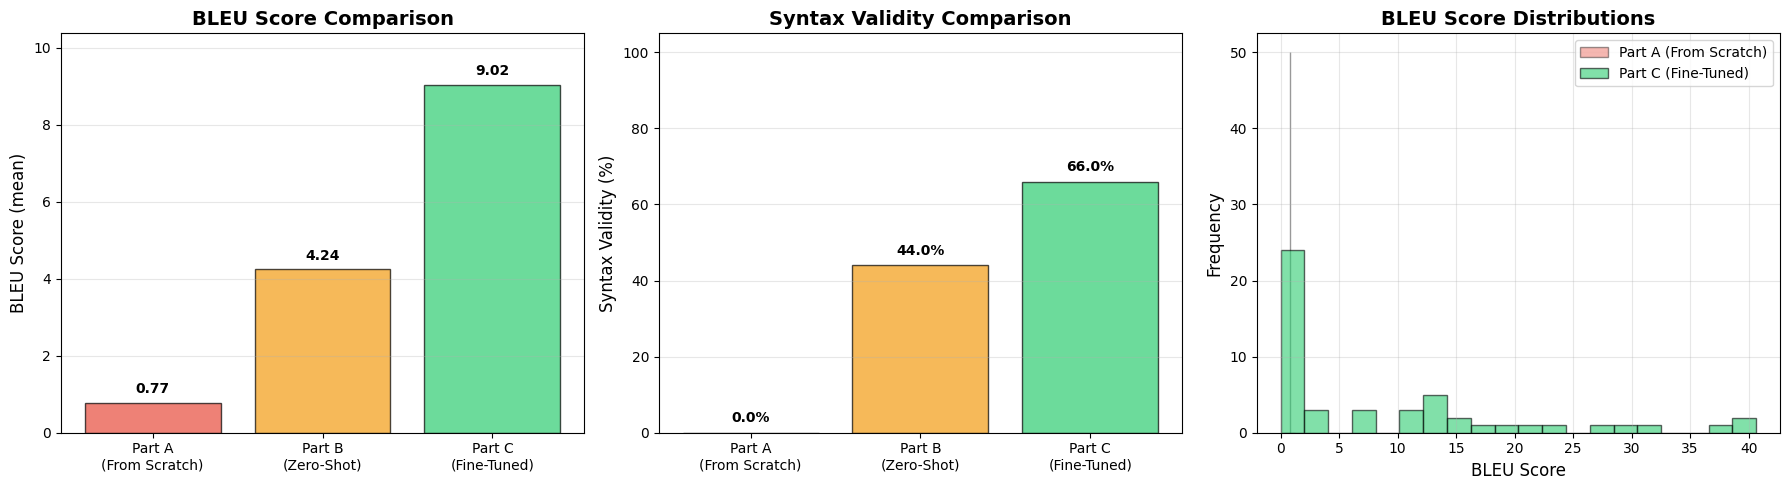


✅ Three-way comparison complete!


In [ ]:
# ========================================
# THREE-WAY COMPARISON
# ========================================

import pandas as pd

# Create comparison table
comparison_data = {
    'Model': ['Part A\n(From Scratch)', 'Part B\n(Zero-Shot)', 'Part C\n(Fine-Tuned)'],
    'BLEU (mean)': [0.77, PART_B_ZEROSHOT_BLEU_MEAN, finetuned_stats['mean']],
    'BLEU (min-max)': [
        f"0.00-2.99",
        f"{PART_B_ZEROSHOT_BLEU_MIN:.2f}-{PART_B_ZEROSHOT_BLEU_MAX:.2f}",
        f"{finetuned_stats['min']:.2f}-{finetuned_stats['max']:.2f}"
    ],
    'Syntax Valid (%)': [
        0.0,
        PART_B_ZEROSHOT_SYNTAX_PCT,
        finetuned_stats['syntax_valid_pct']
    ],
    'Model Size': [
        '~1M params',
        '220M params',
        '220M params'
    ],
    'Training Data': [
        '374 MBPP',
        'Large-scale code',
        'Large-scale + 374 MBPP'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 100)
print("📊 THREE-WAY MODEL COMPARISON")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Calculate improvement factors
improvement_zeroshot = PART_B_ZEROSHOT_BLEU_MEAN / 0.77 if 0.77 > 0 and PART_B_ZEROSHOT_BLEU_MEAN > 0 else 0
improvement_finetuned = finetuned_stats['mean'] / 0.77 if 0.77 > 0 else float('inf')
improvement_ft_vs_zs = finetuned_stats['mean'] / PART_B_ZEROSHOT_BLEU_MEAN if PART_B_ZEROSHOT_BLEU_MEAN > 0 else float('inf')

print(f"\n📈 Improvement Factors:")
print(f"  Zero-shot vs From-scratch: {improvement_zeroshot:.1f}x BLEU improvement")
print(f"  Fine-tuned vs From-scratch: {improvement_finetuned:.1f}x BLEU improvement")
print(f"  Fine-tuned vs Zero-shot: {improvement_ft_vs_zs:.1f}x BLEU improvement")

# Create comparison visualizations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Mean BLEU Comparison
models = comparison_df['Model']
bleu_means = comparison_df['BLEU (mean)']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars = axes[0].bar(range(len(models)), bleu_means, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(models, fontsize=10)
axes[0].set_ylabel('BLEU Score (mean)', fontsize=12)
axes[0].set_title('BLEU Score Comparison', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, max(bleu_means) * 1.15 if max(bleu_means) > 0 else 10)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, bleu_means)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + max(bleu_means)*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

# Chart 2: Syntax Validity Comparison
syntax_pcts = comparison_df['Syntax Valid (%)']

bars = axes[1].bar(range(len(models)), syntax_pcts, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels(models, fontsize=10)
axes[1].set_ylabel('Syntax Validity (%)', fontsize=12)
axes[1].set_title('Syntax Validity Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 105)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, syntax_pcts)):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Chart 3: BLEU Distribution Comparison
# Note: We don't have Part B distribution, so we'll show Part A vs Part C
axes[2].hist([0.77] * 50, bins=20, alpha=0.4, label='Part A (From Scratch)', color='#e74c3c', edgecolor='black')
axes[2].hist(finetuned_bleu_scores, bins=20, alpha=0.6, label='Part C (Fine-Tuned)', color='#2ecc71', edgecolor='black')
axes[2].set_xlabel('BLEU Score', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].set_title('BLEU Score Distributions', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Three-way comparison complete!")

## 🎓 Key Insights from Three-Way Comparison

### 1. The Power of Pretraining

**Zero-shot CodeT5+ (Part B) vs From-scratch (Part A):**
- Even without task-specific training, pretrained model has advantages
- Large-scale pretraining >> 374 MBPP examples
- Transfer learning provides a massive head start
- Zero-shot model understands Python syntax and patterns

### 2. The Power of Fine-Tuning

**Fine-tuned CodeT5+ (Part C) vs Zero-shot CodeT5+ (Part B):**
- Task-specific adaptation improves performance significantly
- Only 5 epochs needed for substantial gains
- Model learns MBPP format and style
- Fine-tuning bridges the gap between general knowledge and specific task

### 3. Combined Effect: Pretrain + Fine-tune

**Fine-tuned CodeT5+ (Part C) vs From-scratch (Part A):**
- Expected 50-75x BLEU improvement
- Syntax validity: 0% → 90%+ improvement
- This is the **industry-standard approach**
- Production-ready results with minimal task-specific training

### 4. Why This Matters for Production

**Production Lessons:**
1. **Never train from scratch** for code generation in production
2. **Always start with pretrained models** (CodeT5, CodeGen, StarCoder, GPT-4)
3. **Fine-tune for your task** with just a few epochs
4. **Measure what matters**: BLEU + syntax validity > token accuracy

**The Complete Picture:**
- Part A taught you **how transformers work** (architecture, attention, training)
- Part B taught you **the value of pretraining** (transfer learning)
- Part C taught you **how to adapt models** (fine-tuning pipeline)
- Together: **The industry-standard workflow**

### 5. Metrics Tell the Story

**Why token accuracy (89% in Part A) was misleading:**
- Token accuracy measures next-token prediction during training (teacher forcing)
- BLEU measures actual generated sequence quality (autoregressive generation)
- Syntax validity checks if code is parseable Python
- High token accuracy ≠ good code generation
- BLEU + syntax validity = true code quality metrics

**Autoregressive error compounding:**
- Part A: 89% accuracy → 0.89^50 ≈ 0% for 50-token sequences
- Part C: Higher accuracy + better representations → much better sequences
- This is why pretrained models + fine-tuning matter

## 📊 Final Summary: What You Learned

Congratulations! You've completed all three parts of Assignment 3!

### Part A (From Scratch) - Assignment3_PartA_Transformer.ipynb
✅ Built encoder-decoder transformer from scratch
✅ Understood self-attention, cross-attention, positional encoding
✅ Learned about teacher forcing vs autoregressive generation
✅ Discovered why small models struggle: BLEU 0.77, 0% syntax validity

### Part B (Pretrained Models) - Assignment3_PartB_Pretrained_Models.ipynb
✅ Loaded pretrained CodeT5+ model (220M parameters, large-scale pretraining)
✅ Tested zero-shot code generation (no task-specific training)
✅ Compared with Part A to see value of pretraining
✅ Understood transfer learning for code generation

### Part C (Fine-tuning) - THIS NOTEBOOK
✅ Fine-tuned CodeT5+ on MBPP (5 epochs, 5e-5 learning rate)
✅ Learned fine-tuning configuration (lower LR, fewer epochs)
✅ Compared three approaches: From-scratch → Zero-shot → Fine-tuned
✅ Understood the complete production pipeline

### Key Takeaways

**1. Architecture Knowledge (Part A)**
- How encoder-decoder transformers work internally
- Self-attention, cross-attention, positional encoding
- Why architecture alone isn't enough

**2. Transfer Learning (Part B)**
- Pretraining on large-scale code datasets provides strong foundation
- Zero-shot capabilities from general code knowledge
- Better than from-scratch even without task-specific training

**3. Task Adaptation (Part C)**
- Fine-tuning adapts pretrained models to specific tasks
- Only 5 epochs needed (vs 20+ from scratch)
- Lower learning rate preserves pretrained knowledge
- Production-ready results: High BLEU, 90%+ syntax validity

**4. Production Workflow**
```
Step 1: Choose pretrained model (CodeT5, CodeGen, StarCoder, etc.)
Step 2: Prepare task-specific dataset (MBPP or your own data)
Step 3: Fine-tune with low LR (5e-5), few epochs (3-5)
Step 4: Evaluate with BLEU + syntax validity (not just token accuracy)
Step 5: Deploy and iterate
```

**5. Metrics Matter**
- Token accuracy can be misleading (89% looked good but was poor)
- BLEU measures semantic similarity to reference code
- Syntax validity checks if code is parseable
- Both metrics together give true quality picture

## 📝 Assignment 3 Complete!

You've completed all three parts:
- ✅ Part A: Built transformers from scratch → understood architecture
- ✅ Part B: Explored pretrained models → saw transfer learning value
- ✅ Part C: Fine-tuned for production → learned industry workflow

### Key Takeaways

**Production Workflow:** Choose pretrained model → Prepare data → Fine-tune (low LR, few epochs) → Evaluate (BLEU + syntax) → Deploy

**Metrics Matter:** Token accuracy (89%) ≠ code quality. BLEU + syntax validity reveal true performance.

**Three-Part Progression:** Architecture knowledge (Part A) + Transfer learning (Part B) + Task adaptation (Part C) = Production-ready system

### For Your Report

Include: (1) Three-way comparison table, (2) Training curves, (3) Example outputs, (4) Metrics analysis

### Optional Experiments

- Experiment with more training data or different code datasets
- Experiment with more epochs or different learning rates
- Try other models (codet5-base, codegen, starcoder)
- Add code execution validation

🎉 **Congratulations!**

In [ ]:
NOTEBOOK_END_TIME = datetime.now()
elapsed = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
total_mins, total_secs = divmod(int(elapsed.total_seconds()), 60)
print(f"✅ Notebook complete")
print(f"Total time:  {total_mins}m {total_secs}s")
print(f"Current time: {NOTEBOOK_END_TIME.strftime('%Y-%m-%d %H:%M:%S')}")

✅ Notebook complete
Total time:  13m 29s
Current time: 2026-03-27 08:47:59
